# Simple Medical Edge Analyzer

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import cv2

## Display Image

In [3]:
img = cv2.imread('Images/chest_xray.JPG')
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

## Detect Edges

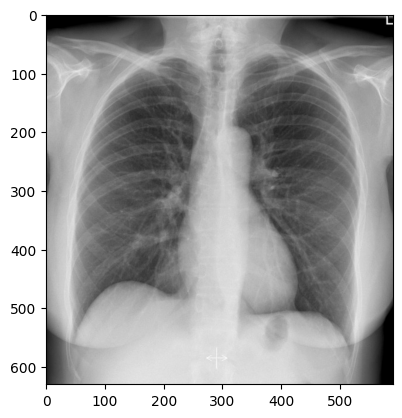

In [4]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
plt.imshow(gray,cmap='gray');

In [10]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)

In [11]:
blurred = cv2.GaussianBlur(gray,(5,5),0)

In [12]:
edges = cv2.Canny(blurred, 30,90)

In [13]:
kernel = np.ones((2,2),np.uint8)
edges_clean = cv2.morphologyEx(edges, cv2.MORPH_CLOSE,kernel)

In [14]:
img_color = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
img_color[edges_clean == 255] = [0,255,0]

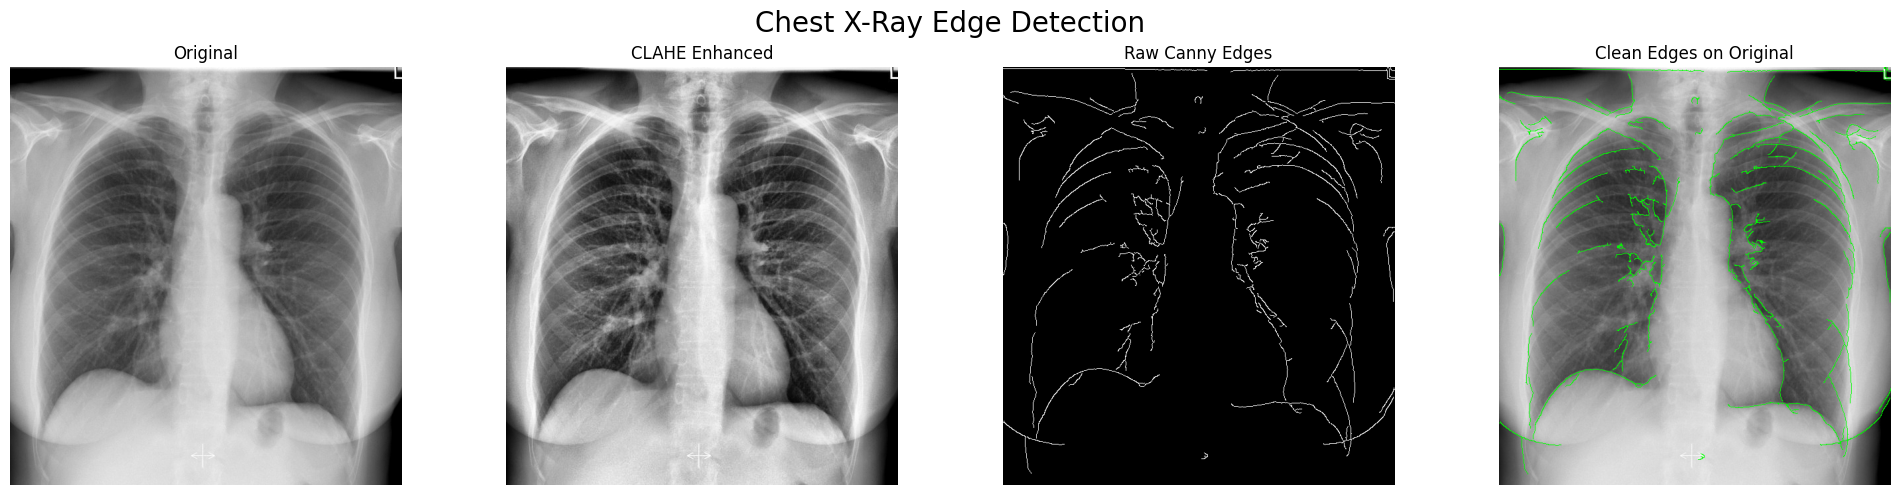

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(enhanced, cmap='gray')
axes[1].set_title('CLAHE Enhanced')
axes[1].axis('off')

axes[2].imshow(edges, cmap='gray')
axes[2].set_title('Raw Canny Edges')
axes[2].axis('off')

axes[3].imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
axes[3].set_title('Clean Edges on Original')
axes[3].axis('off')

plt.suptitle('Chest X-Ray Edge Detection', fontsize=20)
plt.tight_layout()
plt.show()